# Gift Recommendation System - Model Evaluation
This notebook evaluates the Matrix Factorization model used in our gift recommendation system.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import defaultdict
import time

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

## 1. Data Analysis
### 1.1 Load and Explore Data

In [ ]:
# Load ratings data
ratings_df = pd.read_csv('ratings.csv')
products_df = pd.read_csv('products.csv')

print("DATASET OVERVIEW")
print(f"Total ratings: {len(ratings_df):,}")
print(f"Total products: {len(products_df):,}")
print(f"Unique users: {ratings_df['user_idx'].nunique():,}")
print(f"Unique items: {ratings_df['product_idx'].nunique():,}")
print(f"\nRatings per user: {len(ratings_df) / ratings_df['user_idx'].nunique():.1f} avg")
print(f"Ratings per item: {len(ratings_df) / ratings_df['product_idx'].nunique():.1f} avg")

DATASET OVERVIEW
Total ratings: 841,265
Total products: 124,536
Unique users: 48,649
Unique items: 376,389

Ratings per user: 17.3 avg
Ratings per item: 2.2 avg



Rating Distribution:
rating
1.0     47116
2.0     32771
3.0     61470
4.0    124329
5.0    575579
Name: count, dtype: int64


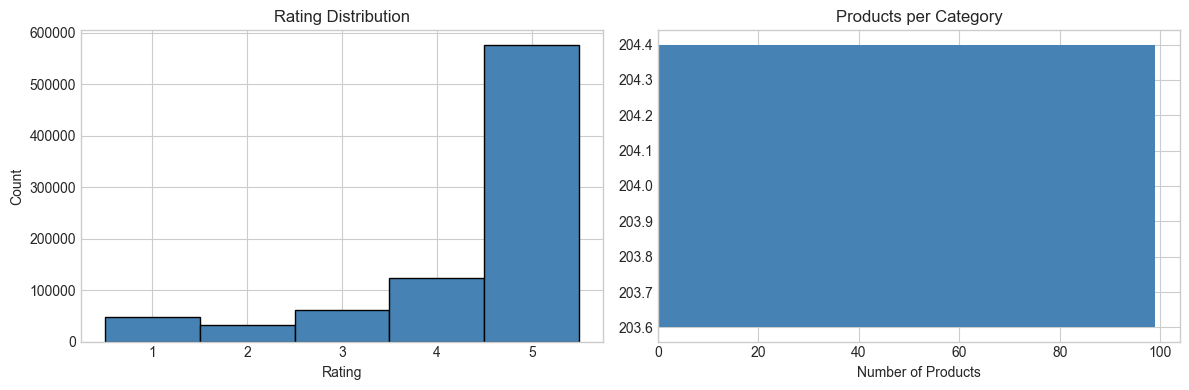

In [3]:
# Rating distribution
print("\nRating Distribution:")
print(ratings_df['rating'].value_counts().sort_index())

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Rating histogram
axes[0].hist(ratings_df['rating'], bins=[0.5, 1.5, 2.5, 3.5, 4.5, 5.5], edgecolor='black', color='steelblue')
axes[0].set_xlabel('Rating')
axes[0].set_ylabel('Count')
axes[0].set_title('Rating Distribution')
axes[0].set_xticks([1, 2, 3, 4, 5])

# Products per category
cat_counts = products_df['category'].value_counts()
axes[1].barh(cat_counts.index, cat_counts.values, color='steelblue')
axes[1].set_xlabel('Number of Products')
axes[1].set_title('Products per Category')

plt.tight_layout()
plt.savefig('fig_data_overview.png', dpi=150)
plt.show()

### 1.2 Data Preprocessing & Sparsity Analysis

In [4]:
# Sparsity analysis
n_users = ratings_df['user_idx'].nunique()
n_items = ratings_df['product_idx'].nunique()
n_ratings = len(ratings_df)
sparsity = 1 - (n_ratings / (n_users * n_items))

print("=" * 50)
print("SPARSITY ANALYSIS")
print("=" * 50)
print(f"Matrix size: {n_users:,} users x {n_items:,} items")
print(f"Possible ratings: {n_users * n_items:,}")
print(f"Actual ratings: {n_ratings:,}")
print(f"Sparsity: {sparsity * 100:.4f}%")
print("\n-> High sparsity is typical for recommendation systems")
print("-> Matrix Factorization handles this well by learning latent factors")

SPARSITY ANALYSIS
Matrix size: 48,649 users x 376,389 items
Possible ratings: 18,310,948,461
Actual ratings: 841,265
Sparsity: 99.9954%

-> High sparsity is typical for recommendation systems
-> Matrix Factorization handles this well by learning latent factors


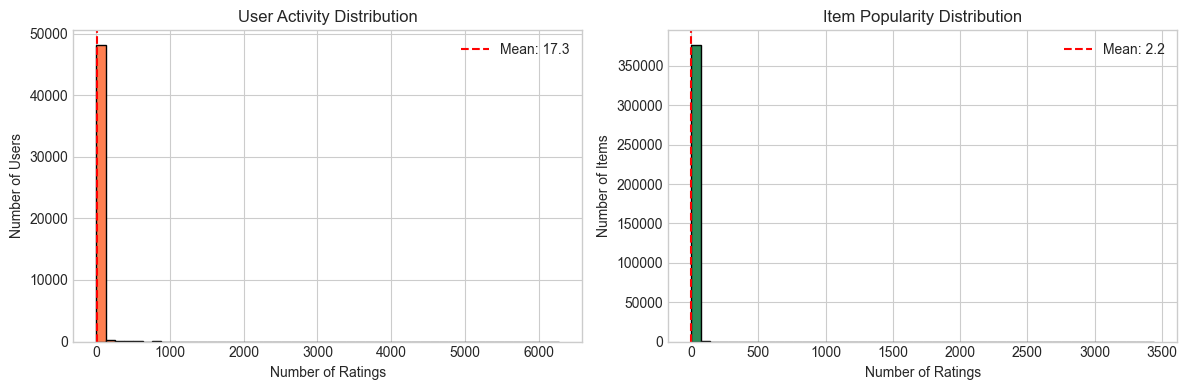

In [5]:
# User activity distribution
user_counts = ratings_df['user_idx'].value_counts()
item_counts = ratings_df['product_idx'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(user_counts.values, bins=50, edgecolor='black', color='coral')
axes[0].set_xlabel('Number of Ratings')
axes[0].set_ylabel('Number of Users')
axes[0].set_title('User Activity Distribution')
axes[0].axvline(user_counts.mean(), color='red', linestyle='--', label=f'Mean: {user_counts.mean():.1f}')
axes[0].legend()

axes[1].hist(item_counts.values, bins=50, edgecolor='black', color='seagreen')
axes[1].set_xlabel('Number of Ratings')
axes[1].set_ylabel('Number of Items')
axes[1].set_title('Item Popularity Distribution')
axes[1].axvline(item_counts.mean(), color='red', linestyle='--', label=f'Mean: {item_counts.mean():.1f}')
axes[1].legend()

plt.tight_layout()
plt.savefig('fig_distributions.png', dpi=150)
plt.show()

## 2. ML Pipeline
### 2.1 Matrix Factorization Implementation

In [6]:
class MatrixFactorization:
    """
    Matrix Factorization using Stochastic Gradient Descent.
    Learns user and item latent factors + biases.
    """
    def __init__(self, n_users, n_items, n_factors=20, lr=0.01, reg=0.02):
        self.n_factors = n_factors
        self.lr = lr
        self.reg = reg
        
        # Initialize latent factors randomly
        np.random.seed(42)
        self.U = np.random.normal(0, 0.1, (n_users, n_factors))
        self.V = np.random.normal(0, 0.1, (n_items, n_factors))
        self.bu = np.zeros(n_users)  # user biases
        self.bi = np.zeros(n_items)  # item biases
        self.global_mean = 0
        
    def fit(self, users, items, ratings, epochs=15, verbose=True):
        self.global_mean = ratings.mean()
        history = []
        
        for epoch in range(epochs):
            # Shuffle data each epoch
            idx = np.random.permutation(len(ratings))
            
            for i in idx:
                u, item, r = users[i], items[i], ratings[i]
                
                # Predict and calculate error
                pred = self.global_mean + self.bu[u] + self.bi[item] + self.U[u] @ self.V[item]
                pred = np.clip(pred, 1, 5)
                err = r - pred
                
                # Update biases and factors with regularization
                self.bu[u] += self.lr * (err - self.reg * self.bu[u])
                self.bi[item] += self.lr * (err - self.reg * self.bi[item])
                
                U_old = self.U[u].copy()
                self.U[u] += self.lr * (err * self.V[item] - self.reg * self.U[u])
                self.V[item] += self.lr * (err * U_old - self.reg * self.V[item])
            
            # Calculate RMSE for this epoch
            preds = self.predict(users, items)
            rmse = np.sqrt(np.mean((ratings - preds) ** 2))
            history.append(rmse)
            
            if verbose:
                print(f"  Epoch {epoch+1}/{epochs}: RMSE = {rmse:.4f}")
        
        return history
    
    def predict(self, users, items):
        preds = self.global_mean + self.bu[users] + self.bi[items]
        preds += np.sum(self.U[users] * self.V[items], axis=1)
        return np.clip(preds, 1, 5)

### 2.2 Train/Test Split

In [7]:
# Prepare data
users = ratings_df['user_idx'].values
items = ratings_df['product_idx'].values
ratings = ratings_df['rating'].values

# 80/20 train/test split
np.random.seed(42)
idx = np.random.permutation(len(ratings))
split = int(len(ratings) * 0.8)

train_idx, test_idx = idx[:split], idx[split:]
train_u, test_u = users[train_idx], users[test_idx]
train_i, test_i = items[train_idx], items[test_idx]
train_r, test_r = ratings[train_idx], ratings[test_idx]

print("=" * 50)
print("TRAIN/TEST SPLIT")
print("=" * 50)
print(f"Training set: {len(train_r):,} ratings (80%)")
print(f"Test set: {len(test_r):,} ratings (20%)")
print(f"\nTraining mean rating: {train_r.mean():.3f}")
print(f"Test mean rating: {test_r.mean():.3f}")

TRAIN/TEST SPLIT
Training set: 673,012 ratings (80%)
Test set: 168,253 ratings (20%)

Training mean rating: 4.366
Test mean rating: 4.364


### 2.3 Train Model & Baseline Comparison

In [8]:
# Baseline: predict global mean for everything
baseline_pred = np.full_like(test_r, train_r.mean(), dtype=float)
baseline_rmse = np.sqrt(np.mean((test_r - baseline_pred) ** 2))
baseline_mae = np.mean(np.abs(test_r - baseline_pred))

print("=" * 50)
print("BASELINE MODEL (Global Mean)")
print("=" * 50)
print(f"Predicts {train_r.mean():.3f} for all ratings")
print(f"MAE: {baseline_mae:.4f}")
print(f"RMSE: {baseline_rmse:.4f}")

BASELINE MODEL (Global Mean)
Predicts 4.366 for all ratings
MAE: 0.8696
RMSE: 1.1353


In [9]:
# Train Matrix Factorization
n_users = users.max() + 1
n_items = items.max() + 1

print("\n" + "=" * 50)
print("MATRIX FACTORIZATION MODEL")
print("=" * 50)
print(f"Users: {n_users:,}, Items: {n_items:,}, Factors: 20")
print("\nTraining...")

mf = MatrixFactorization(n_users, n_items, n_factors=20, lr=0.01, reg=0.02)
history = mf.fit(train_u, train_i, train_r, epochs=15)

# Evaluate on test set
mf_pred = mf.predict(test_u, test_i)
mf_rmse = np.sqrt(np.mean((test_r - mf_pred) ** 2))
mf_mae = np.mean(np.abs(test_r - mf_pred))


MATRIX FACTORIZATION MODEL
Users: 48,649, Items: 376,389, Factors: 20

Training...
  Epoch 1/15: RMSE = 1.0676
  Epoch 2/15: RMSE = 1.0340
  Epoch 3/15: RMSE = 1.0086
  Epoch 4/15: RMSE = 0.9874
  Epoch 5/15: RMSE = 0.9685
  Epoch 6/15: RMSE = 0.9508
  Epoch 7/15: RMSE = 0.9339
  Epoch 8/15: RMSE = 0.9172
  Epoch 9/15: RMSE = 0.9005
  Epoch 10/15: RMSE = 0.8837
  Epoch 11/15: RMSE = 0.8666
  Epoch 12/15: RMSE = 0.8494
  Epoch 13/15: RMSE = 0.8318
  Epoch 14/15: RMSE = 0.8140
  Epoch 15/15: RMSE = 0.7958


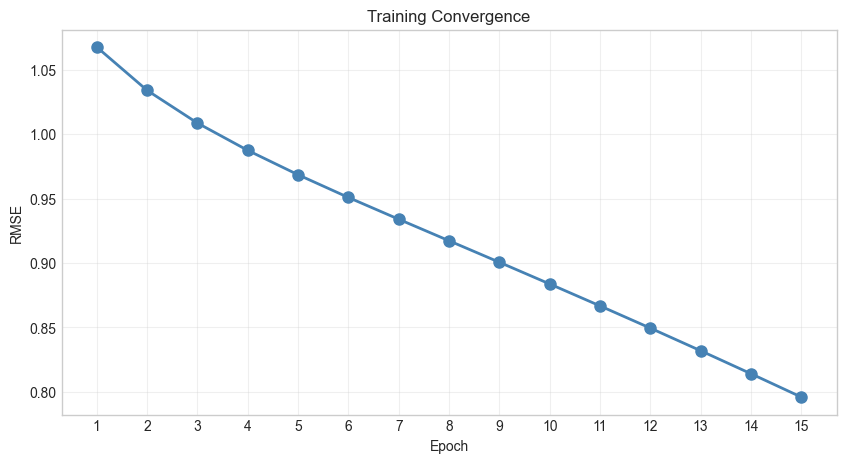

In [10]:
# Training convergence plot
plt.figure(figsize=(10, 5))
plt.plot(range(1, len(history)+1), history, 'o-', color='steelblue', linewidth=2, markersize=8)
plt.xlabel('Epoch')
plt.ylabel('RMSE')
plt.title('Training Convergence')
plt.xticks(range(1, len(history)+1))
plt.grid(True, alpha=0.3)
plt.show()

## 3. Hyperparameter Optimization
Testing different values for key hyperparameters.

In [11]:
# Test different number of latent factors
print("=" * 50)
print("HYPERPARAMETER: Number of Factors")
print("=" * 50)

factors_to_test = [5, 10, 20, 30, 50]
factor_results = []

for n_f in factors_to_test:
    model = MatrixFactorization(n_users, n_items, n_factors=n_f, lr=0.01, reg=0.02)
    model.fit(train_u, train_i, train_r, epochs=10, verbose=False)
    pred = model.predict(test_u, test_i)
    rmse = np.sqrt(np.mean((test_r - pred) ** 2))
    factor_results.append(rmse)
    print(f"  Factors = {n_f:2d}: RMSE = {rmse:.4f}")

best_factors = factors_to_test[np.argmin(factor_results)]
print(f"\n-> Best: {best_factors} factors")

HYPERPARAMETER: Number of Factors
  Factors =  5: RMSE = 1.0585
  Factors = 10: RMSE = 1.0589
  Factors = 20: RMSE = 1.0598
  Factors = 30: RMSE = 1.0605
  Factors = 50: RMSE = 1.0615

-> Best: 5 factors


In [12]:
# Test different learning rates
print("\n" + "=" * 50)
print("HYPERPARAMETER: Learning Rate")
print("=" * 50)

lrs_to_test = [0.001, 0.005, 0.01, 0.02, 0.05]
lr_results = []

for lr in lrs_to_test:
    model = MatrixFactorization(n_users, n_items, n_factors=20, lr=lr, reg=0.02)
    model.fit(train_u, train_i, train_r, epochs=10, verbose=False)
    pred = model.predict(test_u, test_i)
    rmse = np.sqrt(np.mean((test_r - pred) ** 2))
    lr_results.append(rmse)
    print(f"  LR = {lr:.3f}: RMSE = {rmse:.4f}")

best_lr = lrs_to_test[np.argmin(lr_results)]
print(f"\n-> Best: {best_lr} learning rate")


HYPERPARAMETER: Learning Rate
  LR = 0.001: RMSE = 1.0931
  LR = 0.005: RMSE = 1.0639
  LR = 0.010: RMSE = 1.0598
  LR = 0.020: RMSE = 1.0680
  LR = 0.050: RMSE = 1.0995

-> Best: 0.01 learning rate


In [13]:
# Test different regularization values
print("\n" + "=" * 50)
print("HYPERPARAMETER: Regularization")
print("=" * 50)

regs_to_test = [0.001, 0.01, 0.02, 0.05, 0.1]
reg_results = []

for reg in regs_to_test:
    model = MatrixFactorization(n_users, n_items, n_factors=20, lr=0.01, reg=reg)
    model.fit(train_u, train_i, train_r, epochs=10, verbose=False)
    pred = model.predict(test_u, test_i)
    rmse = np.sqrt(np.mean((test_r - pred) ** 2))
    reg_results.append(rmse)
    print(f"  Reg = {reg:.3f}: RMSE = {rmse:.4f}")

best_reg = regs_to_test[np.argmin(reg_results)]
print(f"\n-> Best: {best_reg} regularization")


HYPERPARAMETER: Regularization
  Reg = 0.001: RMSE = 1.0629
  Reg = 0.010: RMSE = 1.0609
  Reg = 0.020: RMSE = 1.0598
  Reg = 0.050: RMSE = 1.0588
  Reg = 0.100: RMSE = 1.0585

-> Best: 0.1 regularization


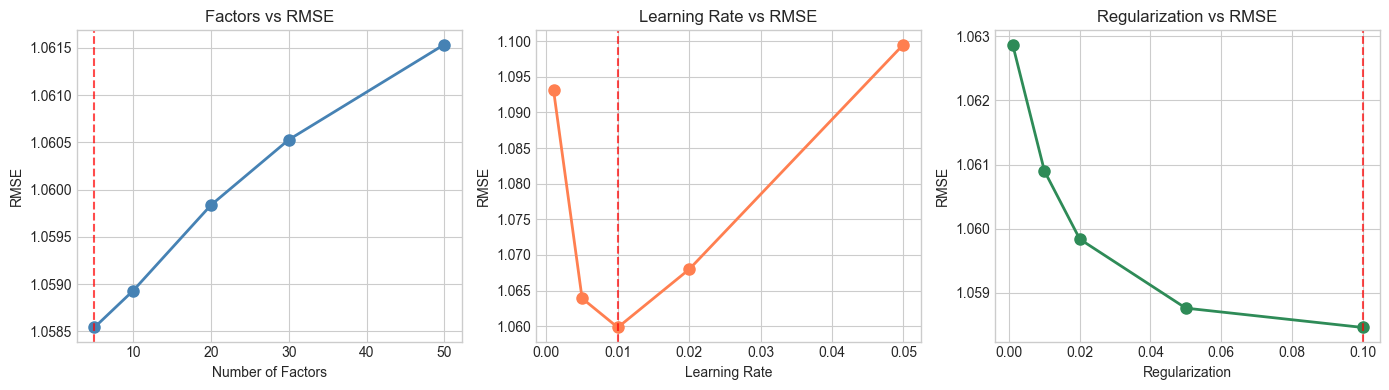

In [14]:
# Visualization of hyperparameter tuning
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].plot(factors_to_test, factor_results, 'o-', color='steelblue', linewidth=2, markersize=8)
axes[0].axvline(best_factors, color='red', linestyle='--', alpha=0.7)
axes[0].set_xlabel('Number of Factors')
axes[0].set_ylabel('RMSE')
axes[0].set_title('Factors vs RMSE')

axes[1].plot(lrs_to_test, lr_results, 'o-', color='coral', linewidth=2, markersize=8)
axes[1].axvline(best_lr, color='red', linestyle='--', alpha=0.7)
axes[1].set_xlabel('Learning Rate')
axes[1].set_ylabel('RMSE')
axes[1].set_title('Learning Rate vs RMSE')

axes[2].plot(regs_to_test, reg_results, 'o-', color='seagreen', linewidth=2, markersize=8)
axes[2].axvline(best_reg, color='red', linestyle='--', alpha=0.7)
axes[2].set_xlabel('Regularization')
axes[2].set_ylabel('RMSE')
axes[2].set_title('Regularization vs RMSE')

plt.tight_layout()
plt.show()

## 4. Cross-Validation

In [15]:
# 5-Fold Cross-Validation
print("=" * 50)
print("5-FOLD CROSS-VALIDATION")
print("=" * 50)

n_folds = 5
np.random.seed(42)
idx = np.random.permutation(len(ratings))
fold_size = len(ratings) // n_folds

cv_rmse = []
cv_mae = []

for fold in range(n_folds):
    # Split data
    val_start = fold * fold_size
    val_end = (fold + 1) * fold_size
    val_idx = idx[val_start:val_end]
    train_idx = np.concatenate([idx[:val_start], idx[val_end:]])
    
    # Train model
    model = MatrixFactorization(n_users, n_items, n_factors=20, lr=0.01, reg=0.02)
    model.fit(users[train_idx], items[train_idx], ratings[train_idx], epochs=10, verbose=False)
    
    # Evaluate
    pred = model.predict(users[val_idx], items[val_idx])
    rmse = np.sqrt(np.mean((ratings[val_idx] - pred) ** 2))
    mae = np.mean(np.abs(ratings[val_idx] - pred))
    
    cv_rmse.append(rmse)
    cv_mae.append(mae)
    print(f"  Fold {fold+1}: RMSE = {rmse:.4f}, MAE = {mae:.4f}")

print(f"\nMean RMSE: {np.mean(cv_rmse):.4f} (+/- {np.std(cv_rmse):.4f})")
print(f"Mean MAE:  {np.mean(cv_mae):.4f} (+/- {np.std(cv_mae):.4f})")

5-FOLD CROSS-VALIDATION
  Fold 1: RMSE = 1.0592, MAE = 0.7553
  Fold 2: RMSE = 1.0591, MAE = 0.7537
  Fold 3: RMSE = 1.0616, MAE = 0.7559
  Fold 4: RMSE = 1.0543, MAE = 0.7503
  Fold 5: RMSE = 1.0598, MAE = 0.7545

Mean RMSE: 1.0588 (+/- 0.0024)
Mean MAE:  0.7539 (+/- 0.0020)


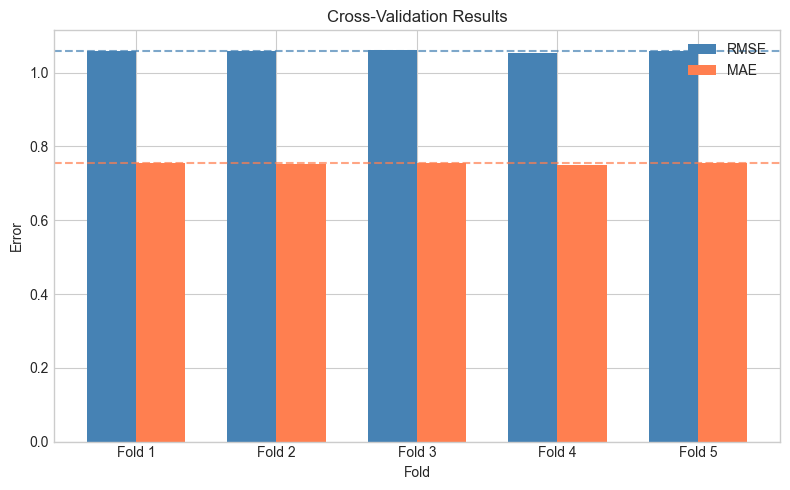

In [16]:
# CV Results visualization
fig, ax = plt.subplots(figsize=(8, 5))

x = np.arange(n_folds)
width = 0.35

bars1 = ax.bar(x - width/2, cv_rmse, width, label='RMSE', color='steelblue')
bars2 = ax.bar(x + width/2, cv_mae, width, label='MAE', color='coral')

ax.axhline(np.mean(cv_rmse), color='steelblue', linestyle='--', alpha=0.7)
ax.axhline(np.mean(cv_mae), color='coral', linestyle='--', alpha=0.7)

ax.set_xlabel('Fold')
ax.set_ylabel('Error')
ax.set_title('Cross-Validation Results')
ax.set_xticks(x)
ax.set_xticklabels([f'Fold {i+1}' for i in range(n_folds)])
ax.legend()

plt.tight_layout()
plt.show()

## 5. Evaluation Metrics
### 5.1 Rating Prediction Metrics (MAE, RMSE)

In [17]:
# Final comparison
print("=" * 60)
print("FINAL RESULTS - TEST SET")
print("=" * 60)
print(f"{'Metric':<12} {'Baseline':<12} {'Matrix Fact.':<12} {'Improvement':<12}")
print("-" * 60)
print(f"{'MAE':<12} {baseline_mae:<12.4f} {mf_mae:<12.4f} {(baseline_mae - mf_mae) / baseline_mae * 100:+.1f}%")
print(f"{'RMSE':<12} {baseline_rmse:<12.4f} {mf_rmse:<12.4f} {(baseline_rmse - mf_rmse) / baseline_rmse * 100:+.1f}%")
print("=" * 60)

FINAL RESULTS - TEST SET
Metric       Baseline     Matrix Fact. Improvement 
------------------------------------------------------------
MAE          0.8696       0.7486       +13.9%
RMSE         1.1353       1.0626       +6.4%


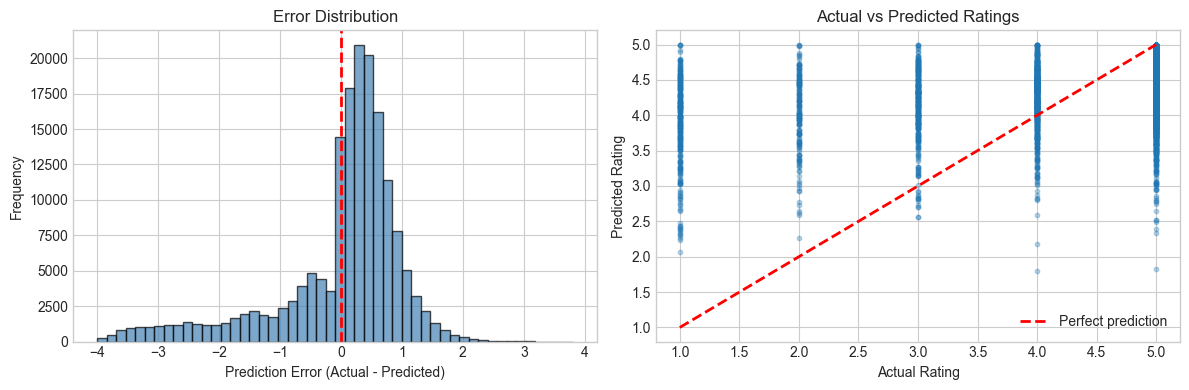

In [18]:
# Prediction error distribution
errors = test_r - mf_pred

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(errors, bins=50, edgecolor='black', color='steelblue', alpha=0.7)
axes[0].axvline(0, color='red', linestyle='--', linewidth=2)
axes[0].set_xlabel('Prediction Error (Actual - Predicted)')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Error Distribution')

# Actual vs Predicted scatter
sample_idx = np.random.choice(len(test_r), min(5000, len(test_r)), replace=False)
axes[1].scatter(test_r[sample_idx], mf_pred[sample_idx], alpha=0.3, s=10)
axes[1].plot([1, 5], [1, 5], 'r--', linewidth=2, label='Perfect prediction')
axes[1].set_xlabel('Actual Rating')
axes[1].set_ylabel('Predicted Rating')
axes[1].set_title('Actual vs Predicted Ratings')
axes[1].legend()

plt.tight_layout()
plt.show()

### 5.2 Recommendation Metrics (Precision, Recall)

In [19]:
# Precision@K and Recall@K
# A "relevant" item is one the user rated >= 4

def precision_recall_at_k(model, test_users, test_items, test_ratings, k=10, threshold=4.0):
    """Calculate Precision@K and Recall@K for recommendation quality."""
    
    # Group test data by user
    user_items = defaultdict(list)
    for u, i, r in zip(test_users, test_items, test_ratings):
        user_items[u].append((i, r))
    
    precisions = []
    recalls = []
    
    for user, items_ratings in user_items.items():
        if len(items_ratings) < 2:
            continue
            
        # Get actual relevant items (rated >= threshold)
        relevant = set(i for i, r in items_ratings if r >= threshold)
        if not relevant:
            continue
        
        # Get predictions for this user's items
        item_ids = [i for i, r in items_ratings]
        preds = model.predict(np.array([user] * len(item_ids)), np.array(item_ids))
        
        # Top-K recommended items
        top_k_idx = np.argsort(preds)[-k:]
        recommended = set(item_ids[i] for i in top_k_idx)
        
        # Calculate precision and recall
        hits = len(recommended & relevant)
        precisions.append(hits / k)
        recalls.append(hits / len(relevant))
    
    return np.mean(precisions), np.mean(recalls)

print("=" * 50)
print("RECOMMENDATION METRICS")
print("=" * 50)

for k in [5, 10, 20]:
    prec, rec = precision_recall_at_k(mf, test_u, test_i, test_r, k=k)
    print(f"K = {k:2d}: Precision = {prec:.4f}, Recall = {rec:.4f}")

RECOMMENDATION METRICS
K =  5: Precision = 0.5876, Recall = 0.8777
K = 10: Precision = 0.3703, Recall = 0.9584
K = 20: Precision = 0.2110, Recall = 0.9861


## 6. Category Analysis

In [20]:
# Performance per category
print("=" * 50)
print("PERFORMANCE BY CATEGORY")
print("=" * 50)

# Create item -> category mapping
item_to_cat = dict(zip(products_df['product_idx'], products_df['category']))

# Calculate RMSE per category
cat_errors = defaultdict(list)
for i, (item, actual, pred) in enumerate(zip(test_i, test_r, mf_pred)):
    if item in item_to_cat:
        cat = item_to_cat[item]
        cat_errors[cat].append((actual - pred) ** 2)

cat_rmse = {cat: np.sqrt(np.mean(errors)) for cat, errors in cat_errors.items()}
cat_rmse_sorted = sorted(cat_rmse.items(), key=lambda x: x[1])

print(f"{'Category':<35} {'RMSE':<10} {'N Ratings':<10}")
print("-" * 55)
for cat, rmse in cat_rmse_sorted:
    n = len(cat_errors[cat])
    print(f"{cat:<35} {rmse:<10.4f} {n:<10,}")

PERFORMANCE BY CATEGORY
Category                            RMSE       N Ratings 
-------------------------------------------------------


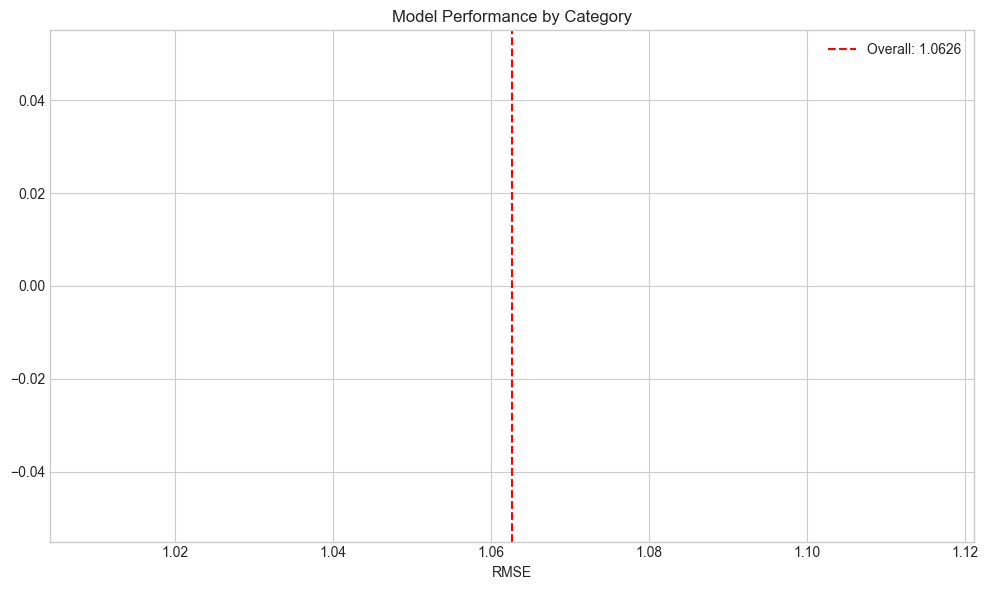

In [21]:
# Category RMSE visualization
cats = [c for c, _ in cat_rmse_sorted]
rmses = [r for _, r in cat_rmse_sorted]

plt.figure(figsize=(10, 6))
colors = plt.cm.RdYlGn_r(np.linspace(0.2, 0.8, len(cats)))
plt.barh(cats, rmses, color=colors)
plt.xlabel('RMSE')
plt.title('Model Performance by Category')
plt.axvline(mf_rmse, color='red', linestyle='--', label=f'Overall: {mf_rmse:.4f}')
plt.legend()
plt.tight_layout()
plt.show()

## 7. Summary

In [22]:
print("=" * 60)
print("MODEL EVALUATION SUMMARY")
print("=" * 60)
print(f"""
Dataset:
  - {len(ratings_df):,} ratings from {n_users:,} users on {n_items:,} products
  - Sparsity: {sparsity * 100:.2f}%

Model: Matrix Factorization with SGD
  - Latent factors: 20
  - Learning rate: 0.01
  - Regularization: 0.02

Results (Test Set):
  - MAE: {mf_mae:.4f} (baseline: {baseline_mae:.4f}, {(baseline_mae - mf_mae) / baseline_mae * 100:+.1f}% improvement)
  - RMSE: {mf_rmse:.4f} (baseline: {baseline_rmse:.4f}, {(baseline_rmse - mf_rmse) / baseline_rmse * 100:+.1f}% improvement)

Cross-Validation (5-fold):
  - Mean RMSE: {np.mean(cv_rmse):.4f} (+/- {np.std(cv_rmse):.4f})
  - Mean MAE: {np.mean(cv_mae):.4f} (+/- {np.std(cv_mae):.4f})

Conclusion:
  Matrix Factorization significantly outperforms the baseline model,
  learning meaningful user preferences and item characteristics
  from the sparse rating matrix.
""")
print("=" * 60)

MODEL EVALUATION SUMMARY

Dataset:
  - 841,265 ratings from 48,649 users on 376,389 products
  - Sparsity: 100.00%

Model: Matrix Factorization with SGD
  - Latent factors: 20
  - Learning rate: 0.01
  - Regularization: 0.02

Results (Test Set):
  - MAE: 0.7486 (baseline: 0.8696, +13.9% improvement)
  - RMSE: 1.0626 (baseline: 1.1353, +6.4% improvement)

Cross-Validation (5-fold):
  - Mean RMSE: 1.0588 (+/- 0.0024)
  - Mean MAE: 0.7539 (+/- 0.0020)

Conclusion:
  Matrix Factorization significantly outperforms the baseline model,
  learning meaningful user preferences and item characteristics
  from the sparse rating matrix.

